In [ ]:
#Import libraries for data analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Upload the cleaned student performance dataset
from google.colab import files
uploaded = files.upload()

Saving students_performance_clean.csv to students_performance_clean.csv


In [ ]:
#Load the cleaned dataset into a DataFrame
df_clean = pd.read_csv("students_performance_clean.csv")

#Preview the first five rows
df_clean.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
#Confirm the dataset dimensions
df_clean.shape

(1000, 8)

In [ ]:
#Reshape math and reading scores for comparison by gender
gender_scores = df_clean.melt(
id_vars="gender",
value_vars=["math score", "reading score"],
var_name="Test",
value_name="Score"
)

#Preview the reshaped data
gender_scores.head()

,gender,Test,Score
0,female,math score,72
1,female,math score,69
2,female,math score,90
3,male,math score,47
4,male,math score,76


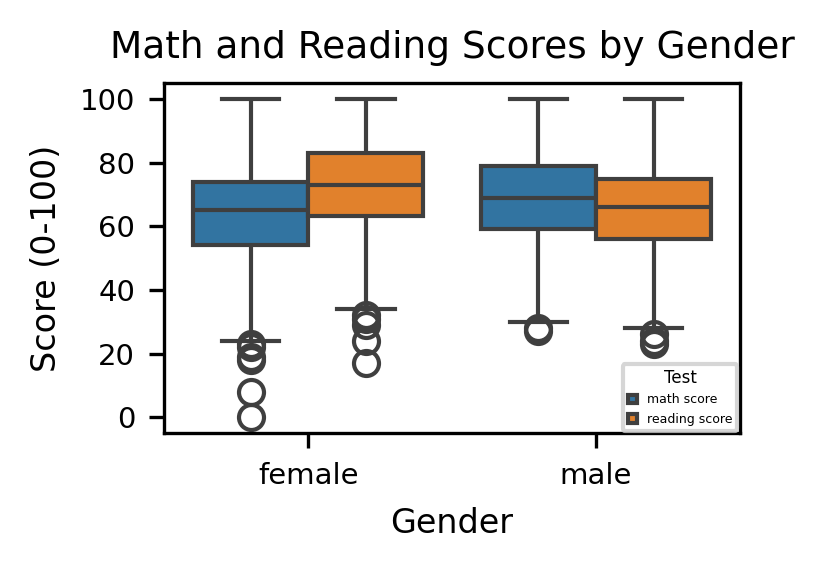

In [ ]:
#Create gender boxplots for math and reading scores
fig, ax = plt.subplots(figsize=(800/300, 600/300), dpi=300)
sns.boxplot(
    data=gender_scores,
    x="gender",
    y="Score",
    hue="Test",
    ax=ax
    )

#Add title and axis labels
ax.set_title("Math and Reading Scores by Gender", fontsize=9)
ax.set_xlabel("Gender", fontsize=8)
ax.set_ylabel("Score (0-100)", fontsize=8)

#Make tick labels readable
ax.tick_params(axis="both", labelsize=7)

#Place a smaller legend inside the upper left
ax.legend(
    title="Test",
    loc="lower right",
    fontsize=3,
    title_fontsize=4,
    borderaxespad=0.2,
    labelspacing=0.50,
    handlelength=.75,
    )
#Reserve space on the right for the legend
fig.subplots_adjust(right=0.70)

#Adjust layout
plt.tight_layout()

#Display the boxplot
plt.show()

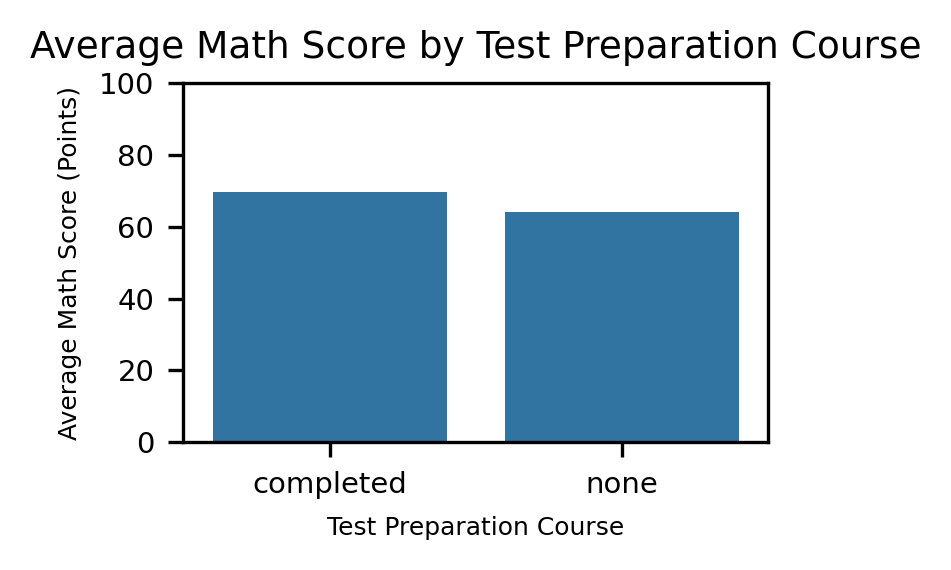

In [ ]:
#Calculate the average math score by test preparation course
test_prep_math = (
df_clean.groupby("test preparation course", as_index=False)["math score"]
.mean()
)

#Create a bar graph of average math scores by test preparation course
fig, ax = plt.subplots(figsize=(800/300, 600/300), dpi=300)
sns.barplot(
data=test_prep_math,
x="test preparation course",
y="math score",
ax=ax
)

#Add title and axis labels
ax.set_title("Average Math Score by Test Preparation Course", fontsize=9)
ax.set_xlabel("Test Preparation Course", fontsize=6)
ax.set_ylabel("Average Math Score (Points)", fontsize=6)

#Make tick labels readable
ax.tick_params(axis="both", labelsize=7)

#Set the math score scale from 0 to 100
ax.set_ylim(0, 100)

#Adjust the layout
plt.tight_layout()

#Display the bar graph
plt.show()

In [ ]:
#Calculate each student's average across all three test scores
df_clean["overall_avg"] = df_clean[
["math score", "reading score", "writing score"]
].mean(axis=1)

In [ ]:
#Calculate the mean overall average by lunch type
lunch_performance = (
df_clean.groupby("lunch", as_index=False)["overall_avg"]
.mean()
)

#Display the results
lunch_performance

,lunch,overall_avg
0,free/reduced,62.199061
1,standard,70.837209


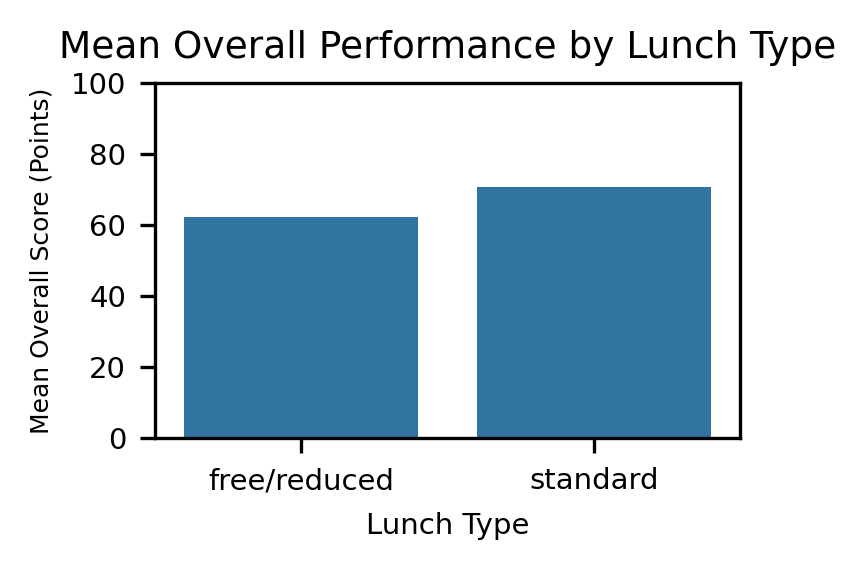

In [ ]:
#Create a bar chart of mean overall performance by lunch type
fig, ax = plt.subplots(figsize=(800/300, 600/300), dpi=300)
sns.barplot(
data=lunch_performance,
x="lunch",
y="overall_avg",
ax=ax
)

#Add title and labeled axes
ax.set_title("Mean Overall Performance by Lunch Type", fontsize=9)
ax.set_xlabel("Lunch Type", fontsize=7)
ax.set_ylabel("Mean Overall Score (Points)", fontsize=6)

#Make tick labels readable
ax.tick_params(axis="both", labelsize=7)

#Set the score axis from 0 to 100
ax.set_ylim(0, 100)

#Adjust the layout
plt.tight_layout()

#Display the chart
plt.show()

In [ ]:
#Calculate correlations among math, reading, and writing scores
score_correlations = df_clean[
["math score", "reading score", "writing score"]
].corr()

#Display the correlation matrix
score_correlations

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [ ]:
#Create shorter labels for the heatmap
score_correlations.columns = ["Math", "Reading", "Writing"]
score_correlations.index = ["Math", "Reading", "Writing"]

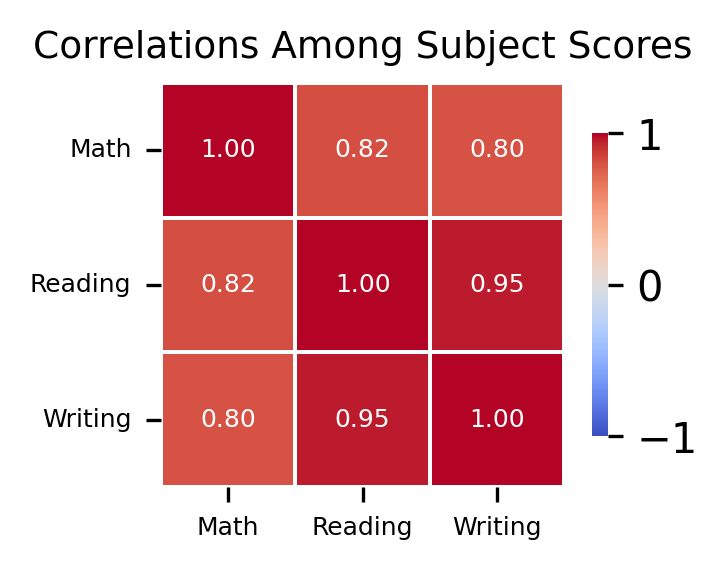

In [ ]:
#Create a correlation heatmap for the three subject scores
fig, ax = plt.subplots(figsize=(800/300, 600/300), dpi=300)
sns.heatmap(
score_correlations,
annot=True,
fmt=".2f",
cmap="coolwarm",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5,
annot_kws={"size": 6},
cbar_kws={"shrink": 0.75},
ax=ax
)

#Add a title
ax.set_title("Correlations Among Subject Scores", fontsize=9)

#Make axis labels readable
ax.tick_params(axis="x", labelsize=6, rotation=0)
ax.tick_params(axis="y", labelsize=6, rotation=0)

#Adjust the layout
plt.tight_layout()

#Display the heatmap
plt.show()

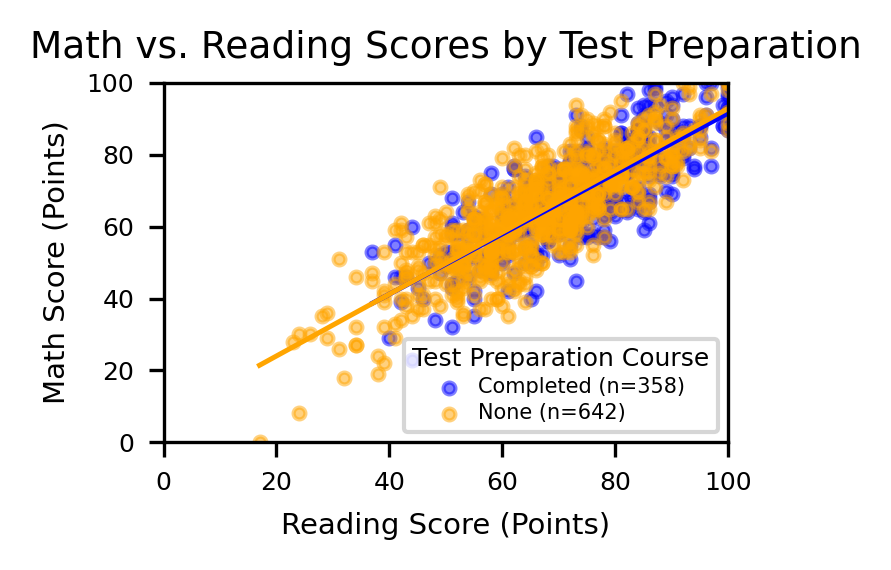

In [ ]:
#Count the number of students in each test preparation group
group_counts = df_clean["test preparation course"].value_counts()

#Define colors for the two groups
colors = {
"completed": "blue",
"none": "orange"
}

#Create the scatter plot
fig, ax = plt.subplots(figsize=(800/300, 600/300), dpi=300)

#Add points and a straight best-fit line for each group
for group in ["completed", "none"]:
  group_data = df_clean[
      df_clean["test preparation course"] == group
      ]
  sns.regplot(
    data=group_data,
    x="reading score",
    y="math score",
    ci=None,
    color=colors[group],
    scatter_kws={"s": 8, "alpha": 0.5},
    line_kws={"linewidth": 1.2},
    label=f"{group.title()} (n={group_counts[group]})",
    ax=ax
    )

#Add title and labeled axes
ax.set_title(
"Math vs. Reading Scores by Test Preparation",
fontsize=9
)
ax.set_xlabel("Reading Score (Points)", fontsize=7)
ax.set_ylabel("Math Score (Points)", fontsize=7)

#Set both score axes from 0 to 100
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

#Make tick labels readable
ax.tick_params(axis="both", labelsize=6)

#Add a legend
ax.legend(
title="Test Preparation Course",
loc="lower right",
fontsize=5,
title_fontsize=6,
borderpad=0.4,
labelspacing=0.3,
handlelength=1.2
)

#Adjust the layout
plt.tight_layout()

#Display the scatter plot
plt.show()

In [16]:
#Save the final analyzed dataset as a CSV file
df_clean.to_csv("student_performance_analyzed.csv", index=False)

In [17]:
#Download the final analyzed dataset
files.download("student_performance_analyzed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>